In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from ptt.io import load_full_sampler_from_filename
from ptt import retrieve_ll
import torch
import h5py
import numpy as np
from rbms.dataset.utils import convert_data, get_covariance_matrix
from tqdm.autonotebook import tqdm
from rbms import load_dataset, load_params, plot_image, plot_mult_PCA
from analysis.utils import load_dataset_analysis
import matplotlib.pyplot as plt

from rbms.utils import (
    compute_log_likelihood,
    get_eigenvalues_history,
    get_flagged_updates,
)

# use LaTeX fonts in the plots
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["font.family"] = "STIXGeneral"
plt.rcParams.update({"font.size": 15})
plt.rcParams["text.usetex"] = True
plt.rcParams["text.latex.preamble"] = r"\usepackage{bm}"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

/home/lorenzo/Documents/rbms/rbms/dataset/dataset_class.py:10: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [22]:
filename = "../models/Globin/embedding_rbm.h5"
train_dataset_name = "../data/Globin/Globin_aligned_noins_nogap.fasta"
test_dataset_name = None

In [23]:
train_dataset, test_dataset = load_dataset(
    dataset_name=train_dataset_name,
    test_dataset_name=test_dataset_name,
    device=device,
    dtype=dtype,
)
num_visibles = train_dataset.get_num_visibles()
num_states = train_dataset.get_num_states()

train_dataset.match_model_variable_type(
    load_params(filename, 1, device, dtype).visible_type
)
# test_dataset.match_model_variable_type(
#     load_params(filename, 1, device, dtype).visible_type
# )

data = train_dataset.data.to(device)
data = torch.nn.functional.one_hot(data.long(), num_classes=num_states).float()
cov_data = get_covariance_matrix(data.view(len(data), -1), train_dataset.weights, device=device).float()
U_data, S_data, V_dataT = torch.linalg.svd(cov_data)

data_proj = data.view(len(data), -1) @ V_dataT.mT
data_proj = data_proj.cpu().numpy() / num_visibles**0.5


Reading dataset from ../data/Globin/Globin_aligned_noins_nogap.fasta...
    Done


In [24]:
from rbms.utils import get_flagged_updates

num_chains = 2000
increment = 1

init_perm_chains = True

start_v = None
if init_perm_chains:
    with h5py.File(filename, "r") as f:
        start_v = torch.from_numpy(f["parallel_chains"][()]).to(
            device=device, dtype=dtype
        )

ptt_updates = get_flagged_updates(filename, "ptt")

sampler = load_full_sampler_from_filename(
    filename,
    num_chains,
    False,
    num_steps=1,
    increment=increment,
    ptt_updates=None,
    dtype=dtype,
    device=device,
)


sampler.init_annealing_chains(num_chains, 100, start_v=None)

The last ptt update '69996' does not correspond to the last saved update '100000'
Selected updates for PTT: [    1   251   316   391   442   677   984  1130  1225  1365  1690  2015
  2531  2989  3626  4596  5913  7692 10225 14813 20503 27346 36357 48466
 69996]


  0%|          | 0/25 [00:00<?, ?it/s]

In [25]:
from rbms.utils import get_saved_updates

saved_updates = get_saved_updates(filename)
all_hbias = []
all_vbias = []
all_weight_matrix = []
all_learning_rates = []
with h5py.File(filename, "r") as f:
    for upd in saved_updates:
        all_hbias.append(f[f"update_{upd}"]["hbias"][()])
        all_vbias.append(f[f"update_{upd}"]["vbias"][()])
        all_weight_matrix.append(f[f"update_{upd}"]["weight_matrix"][()])
        all_learning_rates.append(f[f"update_{upd}"]["learning_rate"][()])
all_vbias = np.asarray(all_vbias).reshape(len(all_vbias), -1)
all_hbias = np.asarray(all_hbias)
all_weight_matrix = np.asarray(all_weight_matrix).reshape(len(all_weight_matrix), -1)
all_learning_rates = np.asarray(all_learning_rates[1:])
x, y = get_eigenvalues_history(filename, backend="gpu")

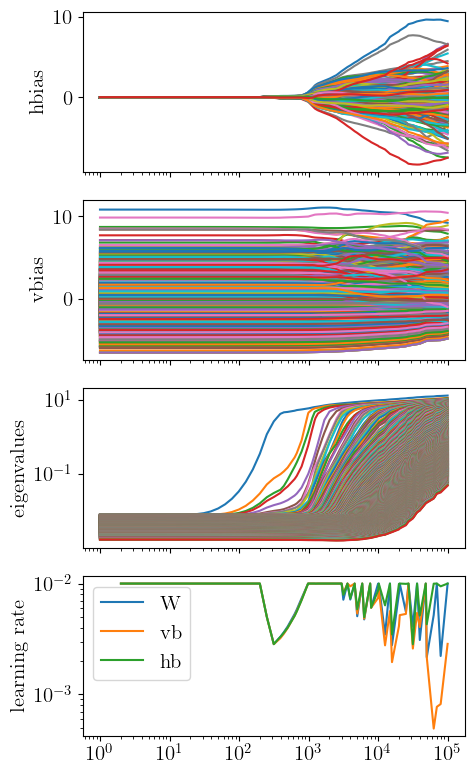

In [26]:
fig, ax = plt.subplots(4, 1, sharex=True, figsize=(5, 8))

ax[0].plot(saved_updates, all_hbias)
ax[1].plot(saved_updates, all_vbias)
ax[2].plot(x, y)
for i, label in enumerate(["W", "vb", "hb"]):
    ax[3].plot(saved_updates[1:], all_learning_rates[:, i], label=label)
ax[3].legend()
ax[0].set_ylabel("hbias")
ax[1].set_ylabel("vbias")
ax[2].set_ylabel("eigenvalues")
ax[2].set_yscale("log")
ax[3].set_ylabel("learning rate")
ax[3].semilogy()
ax[0].semilogx()
fig.tight_layout()

In [27]:
recompute = True
sampler = None
saved_updates, train_ll, test_ll, sampler = retrieve_ll(
    filename,
    train_dataset_name,
    device=device,
    use_weights=False,
    recompute=recompute,
)


Reading dataset from ../data/Globin/Globin_aligned_noins_nogap.fasta...
    Done
Selected updates for PTT: [     1    251    316    391    442    677    984   1130   1225   1365
   1690   2015   2531   2989   3626   4596   5913   7692  10225  14813
  20503  27346  36357  48466  69996 100000]


  0%|          | 0/26 [00:00<?, ?it/s]

  0%|          | 0/5099 [00:00<?, ?it/s]

torch.Size([26])
(26,)


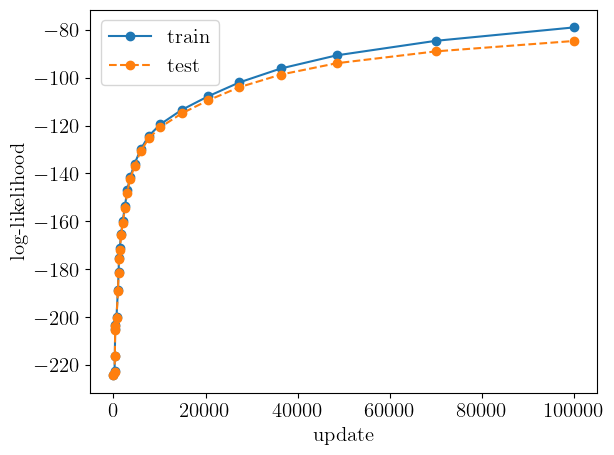

In [28]:
plt.plot(saved_updates, train_ll, "-o", label="train")
if test_ll is not None:
    plt.plot(saved_updates, test_ll, "--o", label="test")
plt.xlabel("update")
plt.ylabel("log-likelihood")
plt.legend()
plt.tight_layout()

In [30]:
# TRWAa
num_chains = 500
tau_int, tau_exp, C = sampler.trwa(
    num_chains=num_chains, increment=increment, filename=filename, force_recompute=False
)
print(f"tau_int: {tau_int}")
print(f"tau_exp: {tau_exp}")

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

total_steps: 100; 20x tau_int: 664.2301177978516, 20x tau_exp: 2682.4386443780204
New number of sampling steps: 2582


  0%|          | 0/2582 [00:00<?, ?it/s]

total_steps: 2682; 20x tau_int: 923.1649780273438, 20x tau_exp: 13653.533991166212
New number of sampling steps: 10971


  0%|          | 0/10971 [00:00<?, ?it/s]

KeyboardInterrupt: 

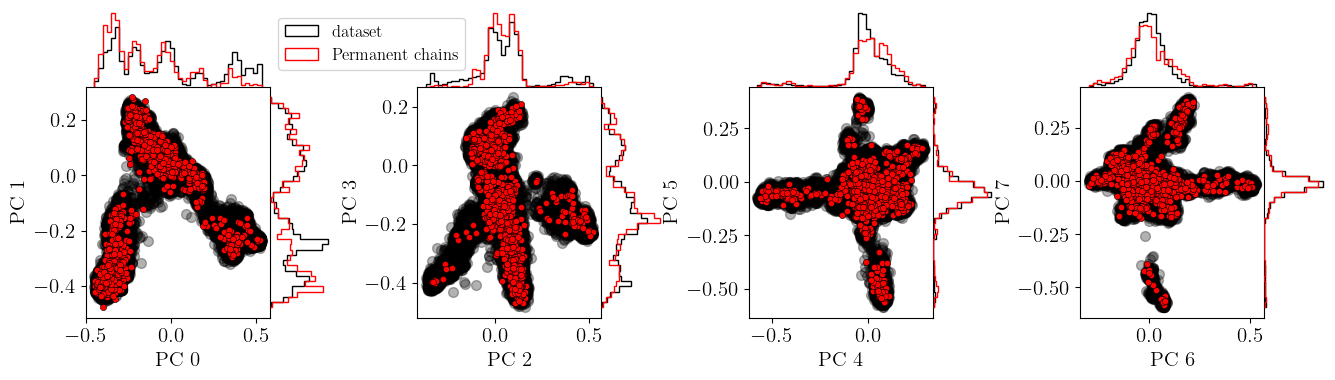

tensor(0.3150, device='cuda:0')


In [29]:
chains = sampler.get_chains(-1)
chains["visible"] = torch.nn.functional.one_hot(
    chains["visible"].long(), num_classes=num_states
).float()
pc_proj = chains["visible"].view(len(chains["visible"]), -1) @ V_dataT.mT
pc_proj = pc_proj.cpu().numpy() / num_visibles**0.5

plot_mult_PCA(
    data_proj[:, :8],
    pc_proj[:, :8],
    labels=["dataset", "Permanent chains"],
)
plt.show()
# if i < len(sampler.acc_rates):
print(sampler.acc_rates[-1])


# Generate large amount of samples


In [31]:
tau_int = 30
tau_exp = 50

num_chains_generation = 200
num_samples_to_generate = 5000
generated_samples = sampler.sample_large(
    num_samples=num_samples_to_generate,
    num_steps_between=int(2 * tau_int + 1),
    num_steps_warmup=int(20 * tau_exp + 1),
    increment=increment,
    out_device="cpu",
    idx_model=-2,
)

  0%|          | 0/1001 [00:00<?, ?it/s]

Sample large:   0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/61 [00:00<?, ?it/s]

  0%|          | 0/61 [00:00<?, ?it/s]

  0%|          | 0/61 [00:00<?, ?it/s]

...

  0%|          | 0/61 [00:00<?, ?it/s]

  0%|          | 0/61 [00:00<?, ?it/s]

  0%|          | 0/61 [00:00<?, ?it/s]

  0%|          | 0/61 [00:00<?, ?it/s]

  0%|          | 0/61 [00:00<?, ?it/s]

In [ ]:
# torch.save(generated_samples, "../models/CM/embedding_rbm_generated_samples.pt")

In [32]:
model = sampler.get_model(-1)
chains = sampler.get_chains(-1)


(<Figure size 1600x1600 with 64 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object))

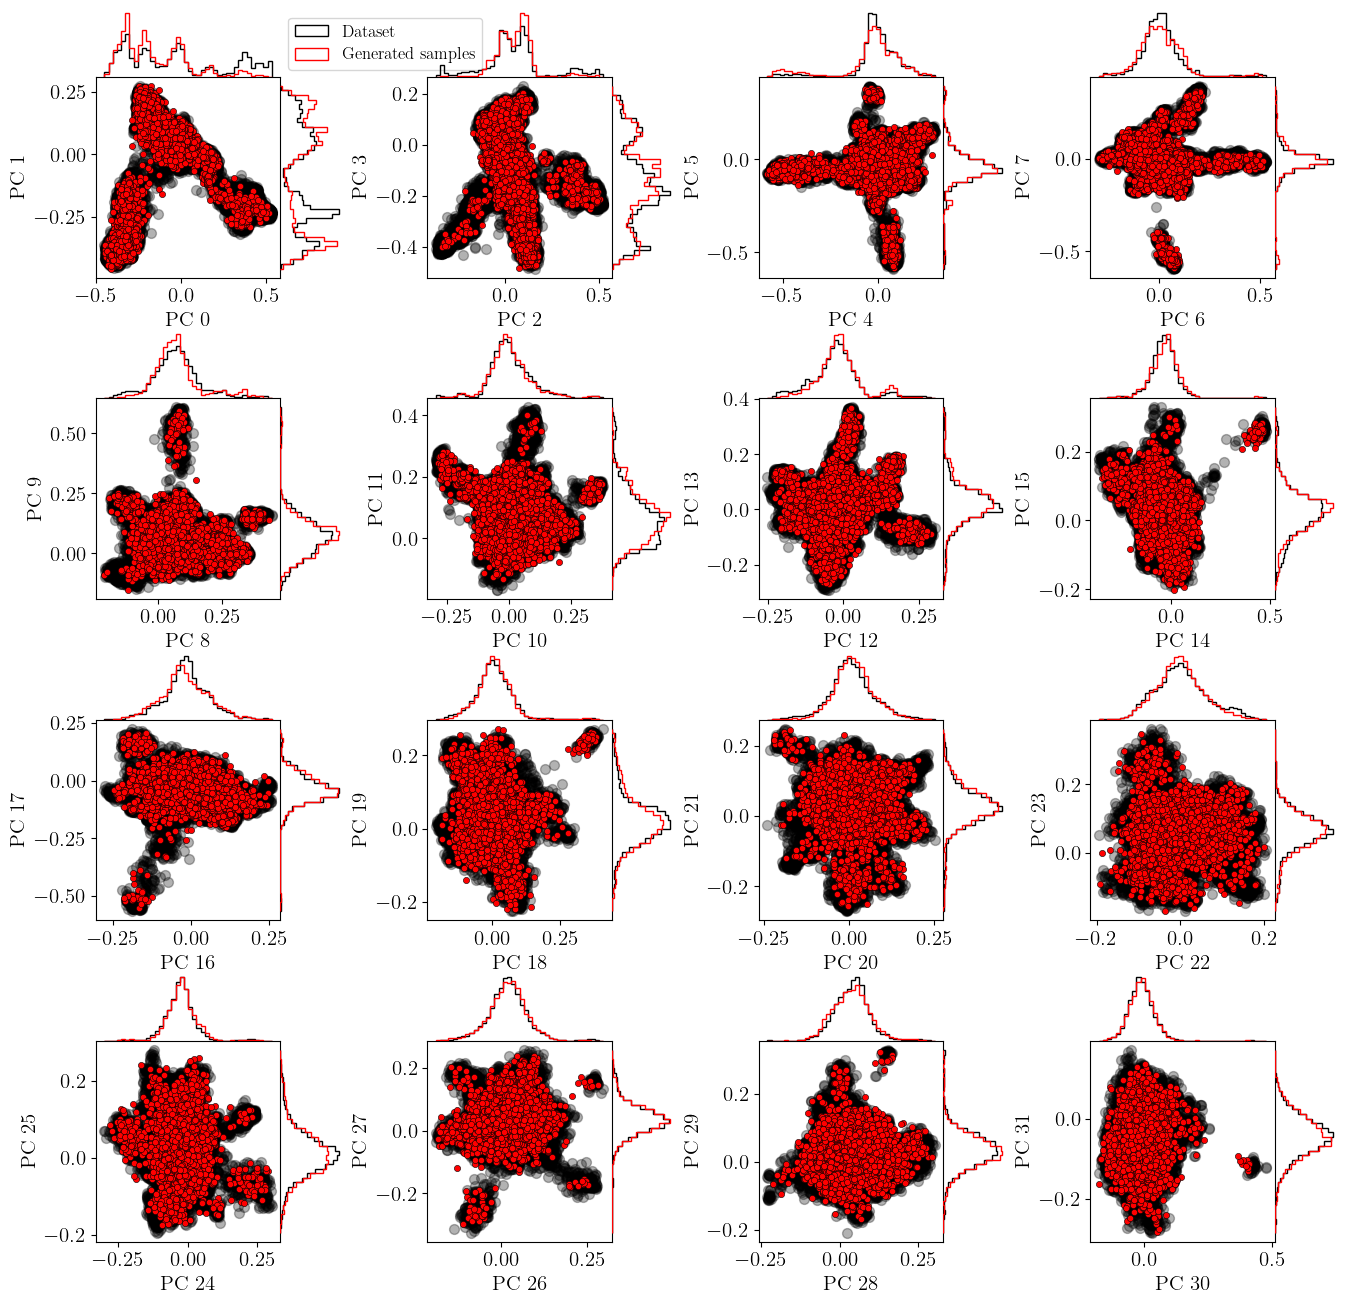

In [33]:
from rbms.custom_fn import one_hot
from rbms.plot import plot_mult_PCA

chains_to_plot = generated_samples["visible"].to(device)
chains_to_plot = torch.nn.functional.one_hot(
    chains_to_plot.long(), num_classes=num_states
).float()
pc_oh = chains_to_plot.view(len(chains_to_plot), -1)
proj_pc = pc_oh @ V_dataT.T / num_visibles**0.5


plot_mult_PCA(
    data_proj[:, :32],
    proj_pc.cpu().numpy()[:, :32],
    labels=["Dataset", "Generated samples"],
)

In [34]:
from analysis.correlations import compute_2b_corr
from rbms.plot import process_corr

# corr_2b_test = compute_2b_corr(test_dataset.data)
corr_2b_train = compute_2b_corr(train_dataset.data)
corr_2b_ptt = compute_2b_corr(generated_samples["visible"])

/home/lorenzo/Documents/rbms/rbms/plot.py:318: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at /pytorch/aten/src/ATen/native/IndexingUtils.h:37.)
  data_1 = data_1[mask]
/home/lorenzo/Documents/rbms/rbms/plot.py:319: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at /pytorch/aten/src/ATen/native/IndexingUtils.h:37.)
  data_2 = data_2[mask]


Text(0.5, 0.98, 'Covariances')

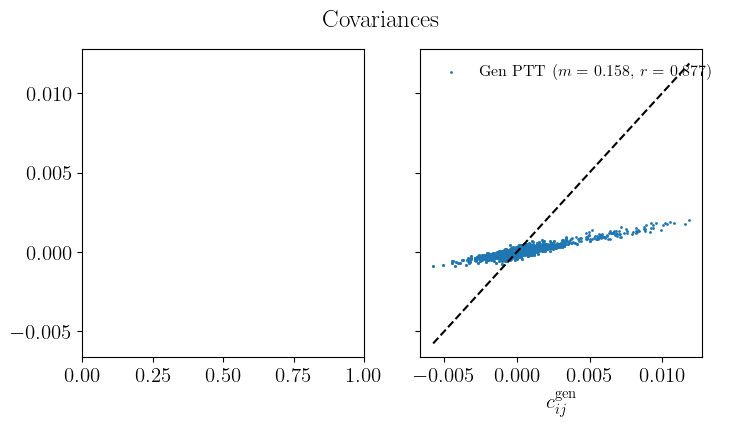

In [35]:
threshold = 0.0

fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

# m2_test, r2_test, x, y, x_line = process_corr(corr_2b_test.cpu(), corr_2b_train.cpu())
# ax[0].scatter(
#     x, y, s=1, label=f"Test ($m=$ {m2_test:.3f}, $r=$ {r2_test:.3f})", rasterized=True
# )
# ax[0].plot(x_line, x_line, "--", color="k")
# ax[0].set_xlabel(r"$c_{ij}^{\mathrm{test}}$")
# ax[0].set_ylabel(r"$c_{ij}^{\mathrm{train}}$")
# ax[0].legend(loc="upper left", fontsize=11.5, frameon=False)

m2_pc, r2_pc, x, y, x_line = process_corr(corr_2b_ptt.cpu(), corr_2b_train.cpu())
ax[1].scatter(
    x, y, s=1, label=f"Gen PTT ($m=$ {m2_pc:.3f}, $r=$ {r2_pc:.3f})", rasterized=True
)
ax[1].plot(x_line, x_line, "--", color="k")
ax[1].set_xlabel(r"$c_{ij}^{\mathrm{gen}}$")
ax[1].legend(loc="upper left", fontsize=11.5, frameon=False)


fig.suptitle("Covariances")